## AttnBLSTM-CNN با استفاده از Keras

Epoch 1/100
560/560 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.7806 - loss: 0.5467 - val_accuracy: 0.7943 - val_loss: 0.4964
Epoch 2/100
560/560 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.7975 - loss: 0.4898 - val_accuracy: 0.8114 - val_loss: 0.4663
Epoch 3/100
560/560 ━━━━━━━━━━━━━━━━━━━━ 14s 25ms/step - accuracy: 0.8027 - loss: 0.4729 - val_accuracy: 0.8179 - val_loss: 0.4410
Epoch 4/100
560/560 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - accuracy: 0.8103 - loss: 0.4485 - val_accuracy: 0.8164 - val_loss: 0.4469
Epoch 5/100
560/560 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.8100 - loss: 0.4419 - val_accuracy: 0.8221 - val_loss: 0.4420
Epoch 6/100
560/560 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.8223 - loss: 0.4280 - val_accuracy: 0.8214 - val_loss: 0.4345
Epoch 7/100
560/560 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.8330 - loss: 0.4082 - val_accuracy: 0.8221 - val_loss: 0.4230
Epoch 8/100
560/560 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.8337 - loss: 0.412

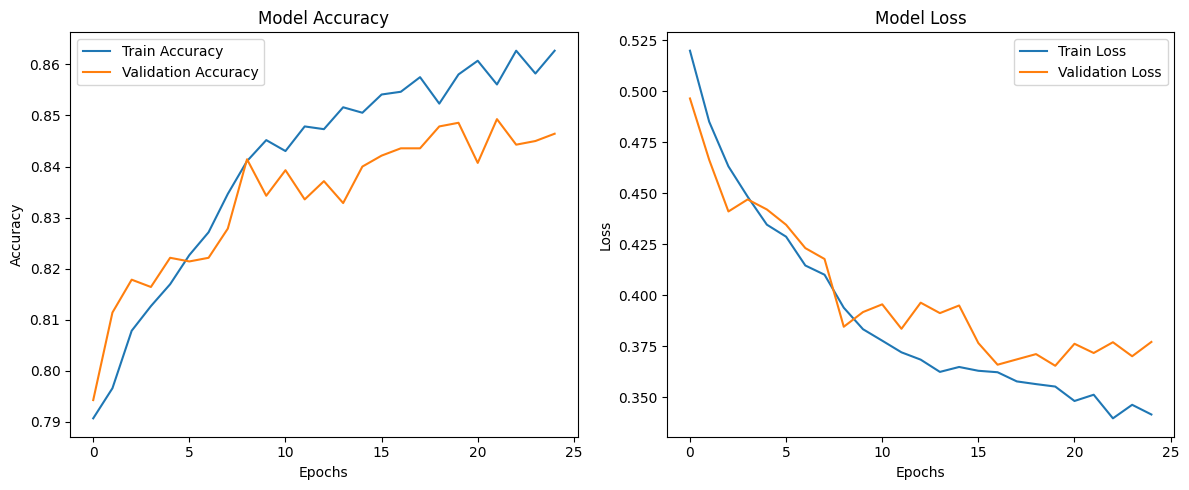

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from keras.models import Model
from keras.layers import Input, Dense, Dropout, LSTM, Conv1D, MaxPooling1D, Flatten, Add
from keras.layers import Bidirectional, Attention
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt



# Remove unnecessary columns
dataset = customer_data.drop(['RowNumber', 'CustomerId', 'Surname', 'Geography'], axis=1)

# Label Encoding for categorical variables
encoder = LabelEncoder()
dataset["Gender"] = encoder.fit_transform(dataset["Gender"])

# Split the data into features and target
X = dataset.drop(['Exited'], axis=1)
Y = dataset['Exited']

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 2: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, Y, test_size=0.3, random_state=42)

# Step 3: Build the AttnBLSTM-CNN model
def create_model(input_shape):
    inputs = Input(shape=input_shape)

    # Bidirectional LSTM layers
    lstm_out = Bidirectional(LSTM(128, return_sequences=True))(inputs)  # Increased LSTM units
    lstm_out = Bidirectional(LSTM(64, return_sequences=True))(lstm_out)  # Second LSTM layer

    # Attention layer
    attention = Attention()([lstm_out, lstm_out])

    # Convolutional layer
    conv_out = Conv1D(filters=64, kernel_size=3, activation='relu')(attention)  # Increased filters
    pooled_out = MaxPooling1D(pool_size=2)(conv_out)

    # Flatten and Dense layers
    flatten_out = Flatten()(pooled_out)
    dense_out = Dense(64, activation='relu')(flatten_out)  # Increased Dense units
    dropout_out = Dropout(0.5)(dense_out)

    # Output layer
    output = Dense(1, activation='sigmoid')(dropout_out)

    model = Model(inputs=inputs, outputs=output)
    return model

# Initialize and compile the model
input_shape = (X_train.shape[1], 1)  # Shape of the input
model = create_model(input_shape)
learning_rate = 0.001  # Set learning rate
model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=learning_rate), metrics=['accuracy'])

# Reshape the data to fit the model
X_train_reshaped = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_reshaped = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# EarlyStopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Step 4: Train the model
history = model.fit(X_train_reshaped, y_train,
                    epochs=100,
                    batch_size=10,
                    validation_split=0.2,
                    callbacks=[early_stopping],
                    verbose=1)

# Step 5: Evaluate the model
y_pred = (model.predict(X_test_reshaped) > 0.5).astype("int32")

# Print evaluation metrics
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

# Plotting accuracy and loss
plt.figure(figsize=(12, 5))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()